In [1]:
# cell 1 — imports and training config
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import json, time
from copy import deepcopy

PROJECT_ROOT  = Path('..')
MANIFEST_PATH = PROJECT_ROOT / 'data' / 'coatings_manifest.csv'
MODELS_DIR    = PROJECT_ROOT / 'models'
REPORTS_DIR   = PROJECT_ROOT / 'reports'
MODELS_DIR.mkdir(exist_ok=True)

df = pd.read_csv(MANIFEST_PATH)
df['abs_path'] = df['path'].apply(lambda p: PROJECT_ROOT.resolve() / p)

DEVICE      = torch.device('cpu')
N_FOLDS     = 5
EPOCHS      = 30
BATCH_SIZE  = 8       # small — only 36 training images per fold
LR          = 1e-3    # high LR is fine — only 8,967 params to move
NUM_WORKERS = 0       # Windows CPU — must be 0

print(f'Device     : {DEVICE}')
print(f'Folds      : {N_FOLDS}')
print(f'Epochs     : {EPOCHS}')
print(f'Batch size : {BATCH_SIZE}')

Device     : cpu
Folds      : 5
Epochs     : 30
Batch size : 8


In [2]:
# cell 2 — dataset, augmentation, model (self-contained for this notebook)
IMAGE_SIZE    = 224
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

LABEL_CLASSES = sorted(df['label'].unique().tolist())
LABEL_TO_IDX  = {lbl: i for i, lbl in enumerate(LABEL_CLASSES)}
IDX_TO_LABEL  = {i: lbl for lbl, i in LABEL_TO_IDX.items()}
df['label_idx'] = df['label'].map(LABEL_TO_IDX)
NUM_CLASSES   = len(LABEL_CLASSES)

def make_train_transforms(vertical_flip_p=0.3):
    return A.Compose([
        A.LongestMaxSize(max_size=IMAGE_SIZE),
        A.PadIfNeeded(IMAGE_SIZE, IMAGE_SIZE, border_mode=cv2.BORDER_CONSTANT, value=0),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=vertical_flip_p),
        A.Rotate(limit=30, border_mode=cv2.BORDER_CONSTANT, value=0, p=0.7),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=0,
                           border_mode=cv2.BORDER_CONSTANT, value=0, p=0.5),
        A.ElasticTransform(alpha=40, sigma=5, p=0.3),
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.7),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=20, p=0.5),
        A.GaussianBlur(blur_limit=(3, 5), p=0.3),
        A.GaussNoise(p=0.15),
        A.CoarseDropout(num_holes_range=(1, 4), hole_height_range=(16, 32),
                        hole_width_range=(16, 32), fill=0, p=0.4),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])

TRAIN_TRANSFORMS = {
    'sagging':   make_train_transforms(vertical_flip_p=0.0),
    '__default': make_train_transforms(vertical_flip_p=0.3),
}

def get_train_transform(label):
    return TRAIN_TRANSFORMS.get(label, TRAIN_TRANSFORMS['__default'])

val_transforms = A.Compose([
    A.LongestMaxSize(max_size=IMAGE_SIZE),
    A.PadIfNeeded(IMAGE_SIZE, IMAGE_SIZE, border_mode=cv2.BORDER_CONSTANT, value=0),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

class CoatingsDataset(Dataset):
    def __init__(self, df, mode='train'):
        self.df   = df.reset_index(drop=True)
        self.mode = mode

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = cv2.imread(str(row['abs_path']))
        if image is None:
            raise FileNotFoundError(f'Cannot read: {row["abs_path"]}')
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.mode == 'train':
            tensor = get_train_transform(row['label'])(image=image)['image']
        else:
            tensor = val_transforms(image=image)['image']
        return tensor, int(row['label_idx'])

def build_model(num_classes, freeze_backbone=True):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4, inplace=True),
        nn.Linear(in_features, num_classes)
    )
    return model

print(f'Classes: {LABEL_CLASSES}')
print('Dataset and model builder ready.')

Classes: ['adhesion_loss', 'blistering', 'chalking', 'corrosion', 'crack_paint', 'fading', 'sagging']
Dataset and model builder ready.


C:\Users\gaura\AppData\Local\Temp\ipykernel_12556\3225624905.py:15: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(IMAGE_SIZE, IMAGE_SIZE, border_mode=cv2.BORDER_CONSTANT, value=0),
C:\Users\gaura\AppData\Local\Temp\ipykernel_12556\3225624905.py:18: UserWarning: Argument(s) 'value' are not valid for transform Rotate
  A.Rotate(limit=30, border_mode=cv2.BORDER_CONSTANT, value=0, p=0.7),
C:\Users\gaura\mambaforge\envs\coating-cv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\Users\gaura\AppData\Local\Temp\ipykernel_12556\3225624905.py:19: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=0,
C:\Users\gaura\AppData\Local\Temp\ipykernel_12556\3225624905.py:42: UserWarning: Argument(s) 'value' are

In [3]:
# cell 3 — one epoch train + val functions

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total


def val_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds       = outputs.argmax(1)
            correct    += (preds == labels).sum().item()
            total      += images.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
    return total_loss / total, correct / total, all_preds, all_labels

print('Training utilities ready.')

Training utilities ready.


In [4]:
# cell 4 — stratified 5-fold cross validation loop

skf         = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(df, df['label_idx'])):
    print(f'\n{"="*50}')
    print(f'  FOLD {fold+1}/{N_FOLDS}')
    print(f'  Train: {len(train_idx)} images  |  Val: {len(val_idx)} images')
    print(f'{"="*50}')

    df_train = df.iloc[train_idx]
    df_val   = df.iloc[val_idx]

    train_ds = CoatingsDataset(df_train, mode='train')
    val_ds   = CoatingsDataset(df_val,   mode='val')

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    model     = build_model(NUM_CLASSES, freeze_backbone=True).to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)   # smoothing helps with small datasets
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR, weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc  = 0.0
    best_model_wts = deepcopy(model.state_dict())

    t0 = time.time()
    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        va_loss, va_acc, preds, labels_true = val_one_epoch(model, val_loader, criterion, DEVICE)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)

        if va_acc > best_val_acc:
            best_val_acc   = va_acc
            best_model_wts = deepcopy(model.state_dict())
            best_preds     = preds
            best_labels    = labels_true

        if epoch % 5 == 0 or epoch == 1:
            print(f'  Epoch {epoch:3d}/{EPOCHS} | '
                  f'train_loss: {tr_loss:.4f}  train_acc: {tr_acc:.3f} | '
                  f'val_loss: {va_loss:.4f}  val_acc: {va_acc:.3f}')

    elapsed = time.time() - t0
    print(f'\n  Best val_acc: {best_val_acc:.3f}  |  Time: {elapsed:.1f}s')

    # Save best checkpoint for this fold
    ckpt_path = MODELS_DIR / f'efficientnet_b0_fold{fold+1}.pth'
    torch.save({'fold': fold+1, 'state_dict': best_model_wts,
                'val_acc': best_val_acc, 'label_classes': LABEL_CLASSES}, ckpt_path)

    fold_results.append({
        'fold':        fold + 1,
        'best_val_acc': best_val_acc,
        'history':     history,
        'best_preds':  best_preds,
        'best_labels': best_labels,
    })

mean_acc = np.mean([r['best_val_acc'] for r in fold_results])
std_acc  = np.std( [r['best_val_acc'] for r in fold_results])
print(f'\n{"="*50}')
print(f'  CV RESULT: {mean_acc:.3f} ± {std_acc:.3f}  (mean ± std val_acc)')
print(f'{"="*50}')


  FOLD 1/5
  Train: 36 images  |  Val: 9 images
  Epoch   1/30 | train_loss: 1.9547  train_acc: 0.111 | val_loss: 1.8676  val_acc: 0.222
  Epoch   5/30 | train_loss: 1.6469  train_acc: 0.639 | val_loss: 1.7534  val_acc: 0.444
  Epoch  10/30 | train_loss: 1.4030  train_acc: 0.639 | val_loss: 1.6148  val_acc: 0.333
  Epoch  15/30 | train_loss: 1.2501  train_acc: 0.806 | val_loss: 1.4587  val_acc: 0.778
  Epoch  20/30 | train_loss: 1.2370  train_acc: 0.750 | val_loss: 1.4643  val_acc: 0.667
  Epoch  25/30 | train_loss: 1.1269  train_acc: 0.861 | val_loss: 1.4746  val_acc: 0.667
  Epoch  30/30 | train_loss: 1.2024  train_acc: 0.722 | val_loss: 1.4745  val_acc: 0.444

  Best val_acc: 0.778  |  Time: 139.8s

  FOLD 2/5
  Train: 36 images  |  Val: 9 images
  Epoch   1/30 | train_loss: 1.9890  train_acc: 0.111 | val_loss: 1.8460  val_acc: 0.444
  Epoch   5/30 | train_loss: 1.6016  train_acc: 0.583 | val_loss: 1.6209  val_acc: 0.556
  Epoch  10/30 | train_loss: 1.3552  train_acc: 0.722 | val_l

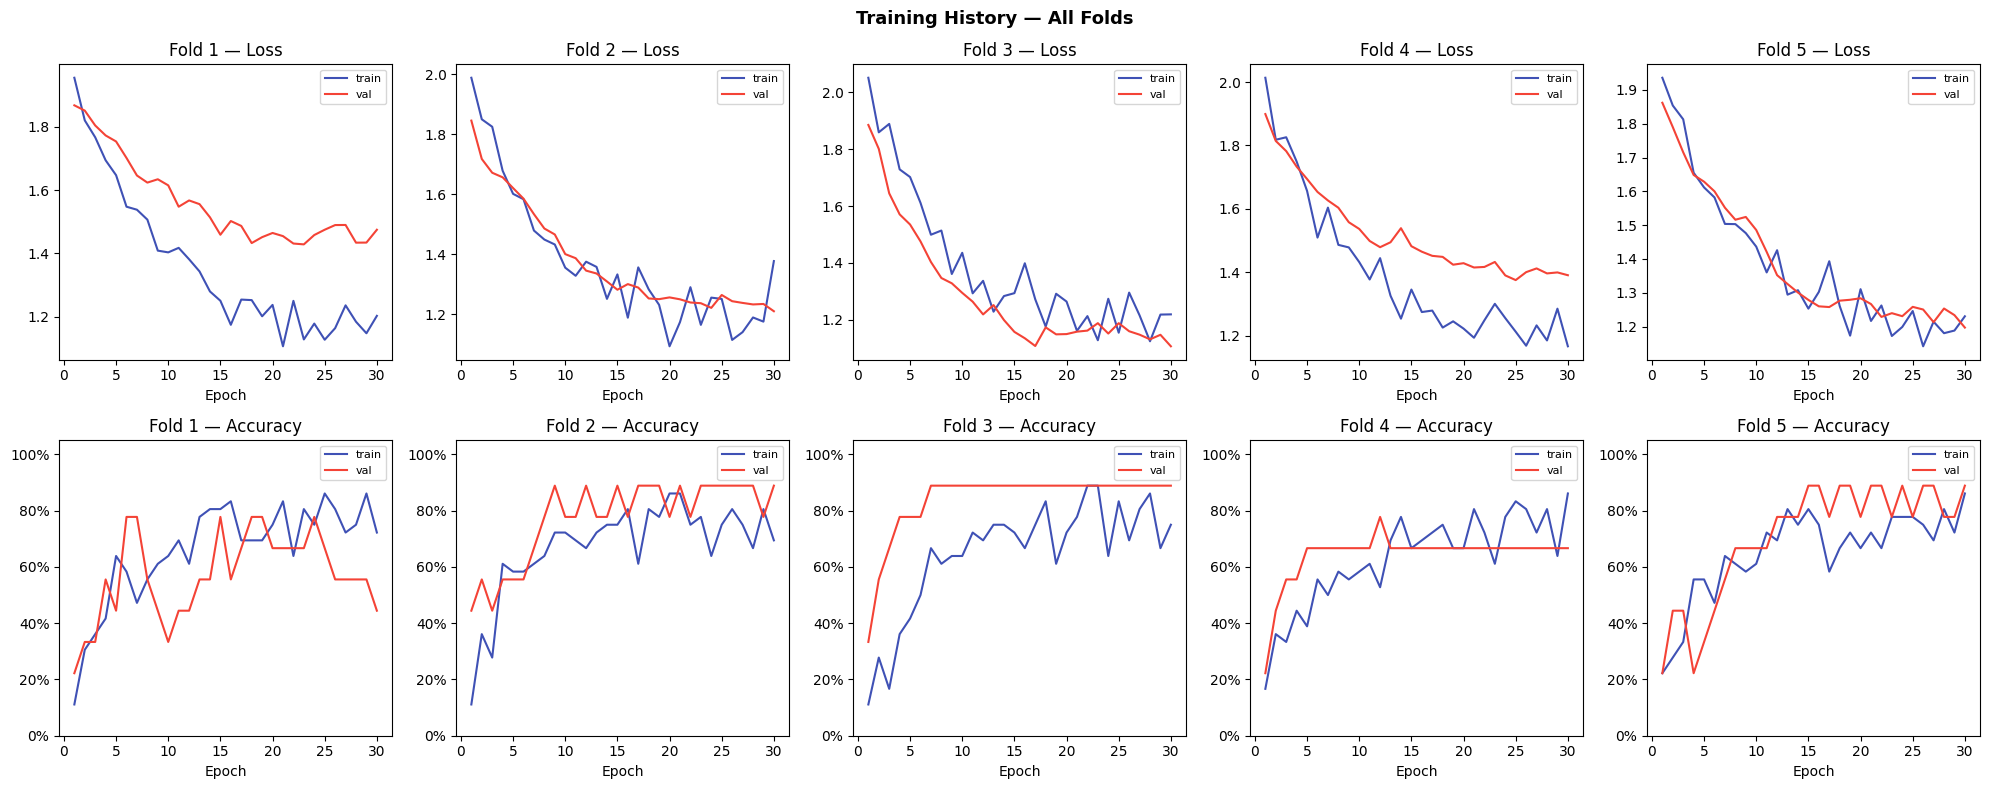

Saved → reports/training_curves.png


In [5]:
# cell 5 — plot training curves for all folds
fig, axes = plt.subplots(2, N_FOLDS, figsize=(N_FOLDS * 4, 8))
fig.suptitle('Training History — All Folds', fontsize=13, fontweight='bold')

for i, res in enumerate(fold_results):
    h = res['history']
    ep = range(1, EPOCHS + 1)

    axes[0, i].plot(ep, h['train_loss'], label='train', color='#3F51B5')
    axes[0, i].plot(ep, h['val_loss'],   label='val',   color='#F44336')
    axes[0, i].set_title(f'Fold {res["fold"]} — Loss')
    axes[0, i].set_xlabel('Epoch')
    axes[0, i].legend(fontsize=8)

    axes[1, i].plot(ep, h['train_acc'], label='train', color='#3F51B5')
    axes[1, i].plot(ep, h['val_acc'],   label='val',   color='#F44336')
    axes[1, i].set_title(f'Fold {res["fold"]} — Accuracy')
    axes[1, i].set_xlabel('Epoch')
    axes[1, i].set_ylim(0, 1.05)
    axes[1, i].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
    axes[1, i].legend(fontsize=8)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/training_curves.png')

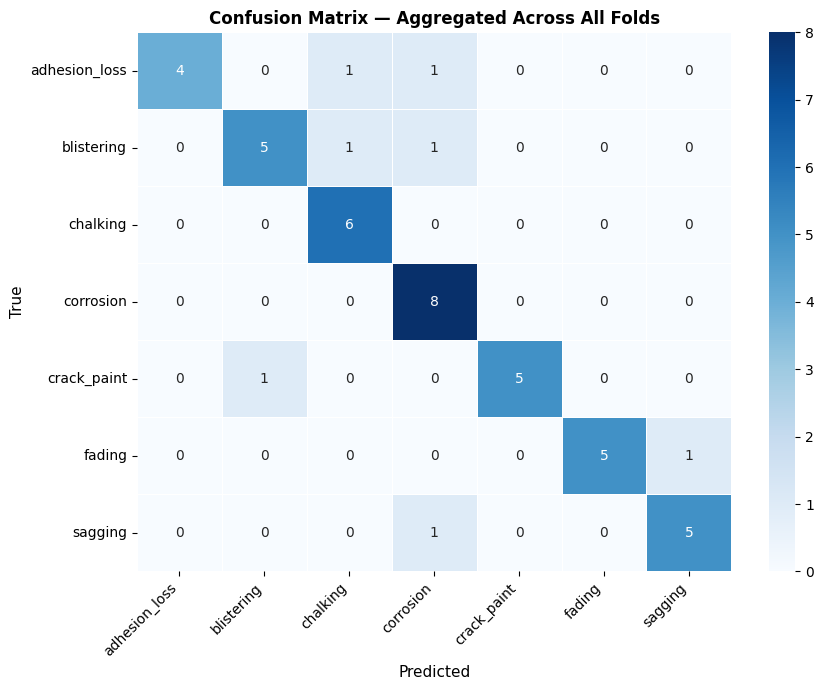


Per-class classification report:
               precision    recall  f1-score   support

adhesion_loss      1.000     0.667     0.800         6
   blistering      0.833     0.714     0.769         7
     chalking      0.750     1.000     0.857         6
    corrosion      0.727     1.000     0.842         8
  crack_paint      1.000     0.833     0.909         6
       fading      1.000     0.833     0.909         6
      sagging      0.833     0.833     0.833         6

     accuracy                          0.844        45
    macro avg      0.878     0.840     0.846        45
 weighted avg      0.870     0.844     0.844        45



In [6]:
# cell 6 — aggregate confusion matrix across all folds
all_preds  = []
all_labels = []
for res in fold_results:
    all_preds.extend(res['best_preds'])
    all_labels.extend(res['best_labels'])

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_CLASSES, yticklabels=LABEL_CLASSES,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True',      fontsize=11)
ax.set_title('Confusion Matrix — Aggregated Across All Folds', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nPer-class classification report:')
print(classification_report(all_labels, all_preds,
                             target_names=LABEL_CLASSES,
                             digits=3))

In [7]:
# cell 7 — fine-tuning: unfreeze top 2 EfficientNet blocks + re-train

FINETUNE_EPOCHS = 20
FINETUNE_LR     = 1e-4   # 10× lower than initial — critical to not destroy backbone

finetune_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(df, df['label_idx'])):
    print(f'\n{"="*50}')
    print(f'  FINE-TUNE FOLD {fold+1}/{N_FOLDS}')
    print(f'{"="*50}')

    # Load the best frozen-head checkpoint for this fold
    ckpt = torch.load(MODELS_DIR / f'efficientnet_b0_fold{fold+1}.pth', 
                      map_location=DEVICE)
    model = build_model(NUM_CLASSES, freeze_backbone=True).to(DEVICE)
    model.load_state_dict(ckpt['state_dict'])

    # Unfreeze the last 2 blocks (blocks 6 and 7) of EfficientNet features
    # EfficientNet-B0 has features[0..8]: 0=stem, 1-7=MBConv blocks, 8=head conv
    blocks_to_unfreeze = [model.features[6], model.features[7], model.features[8]]
    for block in blocks_to_unfreeze:
        for param in block.parameters():
            param.requires_grad = True

    trainable_now = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Trainable params after unfreeze: {trainable_now:,}')

    df_train = df.iloc[train_idx]
    df_val   = df.iloc[val_idx]
    train_loader = DataLoader(CoatingsDataset(df_train, mode='train'),
                              batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    val_loader   = DataLoader(CoatingsDataset(df_val, mode='val'),
                              batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    # Separate LRs: backbone gets 10× less than head
    optimizer = optim.Adam([
        {'params': model.features[6].parameters(), 'lr': FINETUNE_LR * 0.1},
        {'params': model.features[7].parameters(), 'lr': FINETUNE_LR * 0.1},
        {'params': model.features[8].parameters(), 'lr': FINETUNE_LR * 0.5},
        {'params': model.classifier.parameters(),  'lr': FINETUNE_LR},
    ], weight_decay=1e-4)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FINETUNE_EPOCHS)

    best_val_acc   = ckpt['val_acc']   # must beat the frozen baseline
    best_model_wts = deepcopy(model.state_dict())
    history        = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(1, FINETUNE_EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        va_loss, va_acc, preds, labels_true = val_one_epoch(model, val_loader, criterion, DEVICE)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)

        if va_acc > best_val_acc:
            best_val_acc   = va_acc
            best_model_wts = deepcopy(model.state_dict())
            best_preds     = preds
            best_labels    = labels_true

        if epoch % 5 == 0 or epoch == 1:
            print(f'  Epoch {epoch:3d}/{FINETUNE_EPOCHS} | '
                  f'train_loss: {tr_loss:.4f}  train_acc: {tr_acc:.3f} | '
                  f'val_loss: {va_loss:.4f}  val_acc: {va_acc:.3f}')

    print(f'\n  Best val_acc: {best_val_acc:.3f}  (was {ckpt["val_acc"]:.3f} frozen)')

    # Save fine-tuned checkpoint — overwrites only if improved
    torch.save({'fold': fold+1, 'state_dict': best_model_wts,
                'val_acc': best_val_acc, 'label_classes': LABEL_CLASSES,
                'stage': 'finetuned'},
               MODELS_DIR / f'efficientnet_b0_fold{fold+1}_finetuned.pth')

    finetune_results.append({
        'fold': fold+1, 'best_val_acc': best_val_acc,
        'frozen_val_acc': ckpt['val_acc'],
        'history': history, 'best_preds': best_preds, 'best_labels': best_labels,
    })

mean_ft = np.mean([r['best_val_acc'] for r in finetune_results])
std_ft  = np.std( [r['best_val_acc'] for r in finetune_results])
mean_frozen = np.mean([r['frozen_val_acc'] for r in finetune_results])
print(f'\n{"="*50}')
print(f'  FROZEN   CV: {mean_frozen:.3f}')
print(f'  FINETUNED CV: {mean_ft:.3f} ± {std_ft:.3f}')
print(f'  Delta: {mean_ft - mean_frozen:+.3f}')
print(f'{"="*50}')


  FINE-TUNE FOLD 1/5
  Trainable params after unfreeze: 3,164,707
  Epoch   1/20 | train_loss: 1.4694  train_acc: 0.583 | val_loss: 1.6937  val_acc: 0.778
  Epoch   5/20 | train_loss: 1.5529  train_acc: 0.611 | val_loss: 1.6719  val_acc: 0.444
  Epoch  10/20 | train_loss: 1.3831  train_acc: 0.722 | val_loss: 1.7175  val_acc: 0.333
  Epoch  15/20 | train_loss: 1.4268  train_acc: 0.694 | val_loss: 1.6390  val_acc: 0.778
  Epoch  20/20 | train_loss: 1.3858  train_acc: 0.667 | val_loss: 1.5562  val_acc: 0.778

  Best val_acc: 0.889  (was 0.778 frozen)

  FINE-TUNE FOLD 2/5
  Trainable params after unfreeze: 3,164,707
  Epoch   1/20 | train_loss: 1.4405  train_acc: 0.639 | val_loss: 1.4293  val_acc: 0.889
  Epoch   5/20 | train_loss: 1.4205  train_acc: 0.667 | val_loss: 1.3829  val_acc: 0.889
  Epoch  10/20 | train_loss: 1.4604  train_acc: 0.667 | val_loss: 1.3663  val_acc: 0.889
  Epoch  15/20 | train_loss: 1.3168  train_acc: 0.778 | val_loss: 1.3209  val_acc: 0.889
  Epoch  20/20 | train

In [ ]:
# cell 8 — confusion matrix after fine-tuning
ft_preds, ft_labels = [], []
for res in finetune_results:
    ft_preds.extend(res['best_preds'])
    ft_labels.extend(res['best_labels'])

cm_ft = confusion_matrix(ft_labels, ft_preds)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, cm, title in zip(axes,
                          [cm, cm_ft],
                          ['Frozen Head', 'After Fine-tuning']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABEL_CLASSES, yticklabels=LABEL_CLASSES,
                linewidths=0.5, ax=ax)
    ax.set_title(f'Confusion Matrix — {title}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'confusion_matrix_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nFine-tuned classification report:')
print(classification_report(ft_labels, ft_preds, target_names=LABEL_CLASSES, digits=3))